In [1]:
%matplotlib inline

import json
import hashlib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

import sklearn.metrics as skm
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix, brier_score_loss, log_loss

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.features.extract import load_feature_config, extract_features_from_flows, feature_config_hash_text
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
from src.models.train_balanced_bagging_ensemble import run_balanced_bagging
from src.splits.io import load_splits

from src.eval.plots import (
    plot_roc_curves,
    plot_pr_curves,
    plot_confusion_matrices,
    plot_probability_distributions,
)

paths = load_paths()
logger = setup_logger(level="INFO")

features_yaml = paths.configs_dir / "features.yaml"
cfg = load_feature_config(features_yaml)

In [2]:
def apply_split_lists(df: pd.DataFrame, train_list: Path, val_list: Path, test_list: Path, *, split_col: str = "split") -> pd.DataFrame:
    splits = load_splits(train_list, val_list, test_list)

    cap_to_split = {}
    for split_name, caps in splits.items():
        for cid in caps:
            cap_to_split[str(cid)] = split_name

    out = df.copy()
    out["capture_id"] = out["capture_id"].astype(str)
    out[split_col] = out["capture_id"].map(cap_to_split)

    missing_caps = sorted(out.loc[out[split_col].isna(), "capture_id"].unique().tolist())
    if missing_caps:
        raise ValueError(
            f"Found {len(missing_caps)} captures without split assignment. "
            f"Examples: {missing_caps[:10]}"
        )

    return out


def print_split_summary(df: pd.DataFrame, name: str):
    print(f"\n{name} split counts:")
    print(df["split"].value_counts(dropna=False))
    print(f"\n{name} label by split:")
    print(pd.crosstab(df["split"], df["label"]))


def print_capture_summary(df: pd.DataFrame, name: str):
    tmp = (
        df.groupby(["split", "dataset"])["capture_id"]
        .nunique()
        .unstack(fill_value=0)
    )
    print(f"\n{name} unique captures by split/dataset:")
    print(tmp)

In [3]:
logger.info("Loading Data via src/pipeline/data_preparation.py...")
from src.pipeline.data_preparation import load_and_prepare_data

df_all = load_and_prepare_data()

print("\nFINAL combined split counts:")
print(df_all["split"].value_counts())

print("\nFINAL combined label by split:")
print(pd.crosstab(df_all["split"], df_all["label"]))

print("\nFINAL combined dataset by split:")
print(pd.crosstab(df_all["split"], df_all["dataset"]))

print("\nFINAL combined unique captures by split/dataset:")
print(
    df_all.groupby(["split", "dataset"])["capture_id"]
    .nunique()
    .unstack(fill_value=0)
)

2026-03-20 23:00:35 | INFO | ai-vpn-firewall | Loading Data via src/pipeline/data_preparation.py...
2026-03-20 23:00:35 | INFO | ai-vpn-firewall | Loading and processing VNAT...
2026-03-20 23:01:03 | INFO | ai-vpn-firewall | Loading and processing ISCX...
2026-03-20 23:01:49 | INFO | ai-vpn-firewall | Loading and processing USBVPN...
2026-03-20 23:01:49 | INFO | ai-vpn-firewall | Found USBVPN data. Loading pre-extracted features...
2026-03-20 23:01:49 | INFO | ai-vpn-firewall | Data loaded. Shape: (69558, 47)
2026-03-20 23:01:49 | INFO | ai-vpn-firewall | Split counts:
split
train    65661
val       1992
test      1905
Name: count, dtype: int64
2026-03-20 23:01:49 | INFO | ai-vpn-firewall | Dataset counts:
dataset
usbvpn    49650
iscx      11801
vnat       8107
Name: count, dtype: int64

FINAL combined split counts:
split
train    65661
val       1992
test      1905
Name: count, dtype: int64

FINAL combined label by split:
label      0     1
split             
test    1624   281
train 

In [4]:
print("\n" + "=" * 60)
print("LABEL CONSISTENCY CHECK")
print("=" * 60)

print("VNAT VPN label meaning check:")
print(
    df_all[(df_all["dataset"] == "vnat") & (df_all["capture_id"].astype(str).str.startswith("vpn_"))]
    .groupby("capture_id")["label"]
    .mean()
    .head(10)
)

print("\nISCX VPN label meaning check:")
print(
    df_all[(df_all["dataset"] == "iscx") & (df_all["capture_id"].astype(str).str.startswith("vpn_"))]
    .groupby("capture_id")["label"]
    .mean()
    .head(10)
)

print("=" * 60 + "\n")


LABEL CONSISTENCY CHECK
VNAT VPN label meaning check:
capture_id
vpn_netflix_capture2.pcap    1.0
vpn_rdp_capture1.pcap        1.0
vpn_rdp_capture2.pcap        1.0
vpn_rdp_capture_3.pcap       1.0
vpn_rsync_capture1.pcap      1.0
vpn_rsync_capture2.pcap      1.0
vpn_rsync_capture3.pcap      1.0
vpn_scp_capture1.pcap        1.0
vpn_scp_capture2.pcap        1.0
vpn_sftp_capture1.pcap       1.0
Name: label, dtype: float64

ISCX VPN label meaning check:
capture_id
vpn_vpn_aim_chat1a.pcap         1.0
vpn_vpn_aim_chat1b.pcap         1.0
vpn_vpn_bittorrent.pcap         1.0
vpn_vpn_email2a.pcap            1.0
vpn_vpn_email2b.pcap            1.0
vpn_vpn_facebook_audio2.pcap    1.0
vpn_vpn_facebook_chat1a.pcap    1.0
vpn_vpn_facebook_chat1b.pcap    1.0
vpn_vpn_ftps_a.pcap             1.0
vpn_vpn_ftps_b.pcap             1.0
Name: label, dtype: float64



In [5]:
logger.info("Running pre-flight diagnostics...")

temp_pipe = FeaturePipeline().fit(df_all[df_all["split"] == "train"])
feat_cols = temp_pipe.model_feature_names()

print(f"Detected {len(feat_cols)} model features.")
print("First 30 features:", feat_cols[:30])

suspicious = [
    c for c in feat_cols
    if any(x in c.lower() for x in ["id", "label", "split", "pcap", "capture", "file", "dataset"])
]
if suspicious:
    print(f"WARNING: suspicious feature names found: {suspicious}")

X_train_check = temp_pipe.transform(df_all[df_all["split"] == "train"])
variances = X_train_check[feat_cols].var()
zero_var_cols = variances[variances == 0].index.tolist()

if zero_var_cols:
    print(f"WARNING: found {len(zero_var_cols)} zero-variance features: {zero_var_cols}")
else:
    print("No zero-variance model features found.")

2026-03-20 23:01:50 | INFO | ai-vpn-firewall | Running pre-flight diagnostics...
Detected 38 model features.
First 30 features: ['sz_all_mean', 'sz_all_std', 'sz_all_p25', 'sz_all_median', 'sz_all_p75', 'sz_mean_max', 'sz_mean_min', 'sz_std_max', 'sz_std_min', 'iat_all_mean', 'iat_all_std', 'iat_all_p25', 'iat_all_median', 'iat_all_p75', 'iat_mean_max', 'iat_mean_min', 'iat_std_max', 'iat_std_min', 'h_size_all_00', 'h_size_all_01', 'h_size_all_02', 'h_size_all_03', 'h_size_all_04', 'h_size_all_05', 'h_size_all_06', 'h_iat_all_00', 'h_iat_all_01', 'h_iat_all_02', 'h_iat_all_03', 'h_iat_all_04']
No zero-variance model features found.


In [6]:
logger.info("Running random label smoke test...")

df_train_check = df_all[df_all["split"] == "train"].copy()
df_test_check = df_all[df_all["split"] == "test"].copy()

print("TRAIN label counts:", np.bincount(df_train_check["label"].astype(int)))
print("TEST label counts:", np.bincount(df_test_check["label"].astype(int)))

aucs = []
X_test_check = temp_pipe.transform(df_test_check)[feat_cols]
y_test_real = df_test_check["label"].astype(int).to_numpy()

for seed in range(20):
    df_noise = df_train_check.copy()
    df_noise["label"] = np.random.default_rng(seed).permutation(df_noise["label"].values)

    X_noise = temp_pipe.transform(df_noise)[feat_cols]
    y_noise = df_noise["label"].astype(int)

    model_noise = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        eval_metric="logloss",
        random_state=seed,
        n_jobs=1
    )
    model_noise.fit(X_noise, y_noise)

    preds = model_noise.predict_proba(X_test_check)[:, 1]
    score = skm.roc_auc_score(y_test_real, preds)
    aucs.append(score)

    if seed == 0:
        auc_inv = skm.roc_auc_score(y_test_real, 1 - preds)
        print(f"DEBUG (seed 0): AUC(p)={score:.4f}, AUC(1-p)={auc_inv:.4f}")

print(f"Random Label AUCs (Test): {aucs}")
print(f"Mean Random Label AUC: {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}")

2026-03-20 23:01:50 | INFO | ai-vpn-firewall | Running random label smoke test...
TRAIN label counts: [56176  9485]
TEST label counts: [1624  281]
DEBUG (seed 0): AUC(p)=0.4809, AUC(1-p)=0.5191
Random Label AUCs (Test): [0.48091461704328314, 0.5077244359518258, 0.4835014813386393, 0.4105959539294918, 0.5205886348894694, 0.4038148852619953, 0.477468751643497, 0.5232028908016759, 0.5675597794646144, 0.4186907245411356, 0.6097198604561471, 0.33164345318443983, 0.42871276931437685, 0.6118312062829795, 0.46095708500604804, 0.5298141314446996, 0.5156417088862788, 0.5738642339989131, 0.5472351997615834, 0.6264692863278579]
Mean Random Label AUC: 0.5015 +/- 0.0758


In [7]:
logger.info("Running robust capture holdout test (GroupKFold on TRAIN split only)...")

# We only do GroupKFold on VNAT and ISCX, as USBVPN doesn't have true capture boundaries yet
df_train_groupable = df_all[(df_all["split"] == "train") & (df_all["dataset"].isin(["vnat", "iscx"]))].copy()
gkf = GroupKFold(n_splits=5)

holdout_aucs = []

for fold, (tr_idx, te_idx) in enumerate(gkf.split(df_train_groupable, groups=df_train_groupable["capture_id"])):
    df_tr = df_train_groupable.iloc[tr_idx].copy()
    df_te = df_train_groupable.iloc[te_idx].copy()

    if df_te["label"].nunique() < 2:
        print(f"Fold {fold}: skipped (only 1 class in test)")
        continue

    pipe_ho = FeaturePipeline().fit(df_tr)
    ho_feats = pipe_ho.model_feature_names()

    X_tr = pipe_ho.transform(df_tr)[ho_feats]
    X_te = pipe_ho.transform(df_te)[ho_feats]

    model_ho = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        n_jobs=4,
        eval_metric="auc",
        random_state=42 + fold
    )
    model_ho.fit(X_tr, df_tr["label"].astype(int))

    p = model_ho.predict_proba(X_te)[:, 1]
    auc = skm.roc_auc_score(df_te["label"].astype(int), p)
    holdout_aucs.append(auc)
    print(f"Fold {fold}: AUC = {auc:.4f}")

if holdout_aucs:
    print(f"GroupKFold AUC mean±std: {np.mean(holdout_aucs):.4f} +/- {np.std(holdout_aucs):.4f}")
else:
    print("WARNING: no valid holdout runs completed.")

2026-03-20 23:02:16 | INFO | ai-vpn-firewall | Running robust capture holdout test (GroupKFold on TRAIN split only)...
Fold 0: AUC = 0.9664
Fold 1: AUC = 0.9989
Fold 2: AUC = 0.9794
Fold 3: AUC = 0.9945
Fold 4: AUC = 0.9988
GroupKFold AUC mean±std: 0.9876 +/- 0.0128


In [8]:
logger.info("Running VNAT -> ISCX smoke test...")

vnat_train_only = df_all[(df_all["dataset"] == "vnat") & (df_all["split"] == "train")].copy()
iscx_test_only = df_all[(df_all["dataset"] == "iscx") & (df_all["split"] == "test")].copy()

if len(vnat_train_only) > 0 and len(iscx_test_only) > 0:
    pipe_cross = FeaturePipeline().fit(vnat_train_only)
    cross_feats = pipe_cross.model_feature_names()

    X_cross_train = pipe_cross.transform(vnat_train_only)[cross_feats]
    X_cross_test = pipe_cross.transform(iscx_test_only)[cross_feats]

    print("DEBUG Cross-Domain:")
    print("VNAT train shape:", X_cross_train.shape)
    print("ISCX test shape:", X_cross_test.shape)
    print("ISCX test label counts:", np.bincount(iscx_test_only["label"].astype(int)))

    model_cross = xgb.XGBClassifier(
        n_estimators=30,
        max_depth=3,
        learning_rate=0.1,
        n_jobs=4,
        eval_metric="auc",
        random_state=42
    )
    model_cross.fit(X_cross_train, vnat_train_only["label"].astype(int))

    preds_cross = model_cross.predict_proba(X_cross_test)[:, 1]

    auc_cross = skm.roc_auc_score(iscx_test_only["label"].astype(int), preds_cross)
    auc_cross_inv = skm.roc_auc_score(iscx_test_only["label"].astype(int), 1 - preds_cross)

    print(f"VNAT -> ISCX AUC: {auc_cross:.4f}")
    print(f"VNAT -> ISCX AUC(1-p): {auc_cross_inv:.4f}")

    if auc_cross_inv > 0.60:
        print("WARNING: inverted AUC is high. Check label/domain alignment.")

2026-03-20 23:02:18 | INFO | ai-vpn-firewall | Running VNAT -> ISCX smoke test...
DEBUG Cross-Domain:
VNAT train shape: (7750, 38)
ISCX test shape: (1634, 38)
ISCX test label counts: [1396  238]
VNAT -> ISCX AUC: 0.1628
VNAT -> ISCX AUC(1-p): 0.8372


In [9]:
print("\n" + "=" * 60)
print("ADVANCED ROBUSTNESS EVALUATION")
print("=" * 60)

for dataset_name in ["vnat", "iscx"]:
    print(f"\n--- {dataset_name.upper()} GroupKFold (Train Split Only) ---")
    df_ds = df_all[(df_all["dataset"] == dataset_name) & (df_all["split"] == "train")].copy()

    if df_ds.empty:
        print(f"No train data for {dataset_name}")
        continue

    gkf_ds = GroupKFold(n_splits=5)
    ds_aucs = []

    for fold, (tr_idx, te_idx) in enumerate(gkf_ds.split(df_ds, groups=df_ds["capture_id"])):
        df_tr = df_ds.iloc[tr_idx].copy()
        df_te = df_ds.iloc[te_idx].copy()

        if df_te["label"].nunique() < 2:
            continue

        pipe_ds = FeaturePipeline().fit(df_tr)
        feats_ds = pipe_ds.model_feature_names()

        X_tr = pipe_ds.transform(df_tr)[feats_ds]
        X_te = pipe_ds.transform(df_te)[feats_ds]

        model_ds = xgb.XGBClassifier(
            n_estimators=100,
            max_depth=3,
            eval_metric="auc",
            n_jobs=1,
            random_state=42
        )
        model_ds.fit(X_tr, df_tr["label"].astype(int))

        p = model_ds.predict_proba(X_te)[:, 1]
        ds_aucs.append(skm.roc_auc_score(df_te["label"].astype(int), p))

    if ds_aucs:
        print(f"{dataset_name.upper()} GroupKFold AUC: {np.mean(ds_aucs):.4f} +/- {np.std(ds_aucs):.4f}")


ADVANCED ROBUSTNESS EVALUATION

--- VNAT GroupKFold (Train Split Only) ---
VNAT GroupKFold AUC: 1.0000 +/- 0.0000

--- ISCX GroupKFold (Train Split Only) ---
ISCX GroupKFold AUC: 0.9886 +/- 0.0141


In [10]:
print("\n--- Bidirectional Cross-Domain Test (Full Dataset) ---")

vnat_full = df_all[df_all["dataset"] == "vnat"].copy()
iscx_full = df_all[df_all["dataset"] == "iscx"].copy()

if not vnat_full.empty and not iscx_full.empty:
    pipe_v2i = FeaturePipeline().fit(vnat_full)
    feats_v2i = pipe_v2i.model_feature_names()

    model_v2i = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        eval_metric="auc",
        n_jobs=4,
        random_state=42
    )
    model_v2i.fit(pipe_v2i.transform(vnat_full)[feats_v2i], vnat_full["label"].astype(int))
    p_iscx = model_v2i.predict_proba(pipe_v2i.transform(iscx_full)[feats_v2i])[:, 1]
    auc_v2i = skm.roc_auc_score(iscx_full["label"].astype(int), p_iscx)
    print(f"Train VNAT (All) -> Test ISCX (All): AUC = {auc_v2i:.4f}")

    pipe_i2v = FeaturePipeline().fit(iscx_full)
    feats_i2v = pipe_i2v.model_feature_names()

    model_i2v = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        eval_metric="auc",
        n_jobs=4,
        random_state=42
    )
    model_i2v.fit(pipe_i2v.transform(iscx_full)[feats_i2v], iscx_full["label"].astype(int))
    p_vnat = model_i2v.predict_proba(pipe_i2v.transform(vnat_full)[feats_i2v])[:, 1]
    auc_i2v = skm.roc_auc_score(vnat_full["label"].astype(int), p_vnat)
    print(f"Train ISCX (All) -> Test VNAT (All): AUC = {auc_i2v:.4f}")


--- Bidirectional Cross-Domain Test (Full Dataset) ---
Train VNAT (All) -> Test ISCX (All): AUC = 0.2946
Train ISCX (All) -> Test VNAT (All): AUC = 0.7805


In [11]:
print("\n" + "=" * 60)
print("ABLATION: IMPACT OF USBVPN ON GENERALIZATION")
print("=" * 60)

# We want to see how training on [VNAT+ISCX] vs [VNAT+ISCX+USBVPN] impacts performance on USBVPN Test set.

usbvpn_test = df_all[(df_all["dataset"] == "usbvpn") & (df_all["split"] == "test")].copy()

if not usbvpn_test.empty:
    # 1. Train on VNAT + ISCX only
    df_train_legacy = df_all[(df_all["split"] == "train") & (df_all["dataset"].isin(["vnat", "iscx"]))].copy()

    pipe_legacy = FeaturePipeline().fit(df_train_legacy)
    feats_legacy = pipe_legacy.model_feature_names()

    X_train_legacy = pipe_legacy.transform(df_train_legacy)[feats_legacy]
    y_train_legacy = df_train_legacy["label"].astype(int)

    model_legacy = xgb.XGBClassifier(n_estimators=200, max_depth=3, eval_metric="auc", random_state=42, n_jobs=4)
    model_legacy.fit(X_train_legacy, y_train_legacy)

    X_test_legacy = pipe_legacy.transform(usbvpn_test)[feats_legacy]
    p_legacy = model_legacy.predict_proba(X_test_legacy)[:, 1]
    auc_legacy = skm.roc_auc_score(usbvpn_test["label"].astype(int), p_legacy)

    # 2. Train on Multi-Domain (VNAT + ISCX + USBVPN)
    df_train_multi = df_all[df_all["split"] == "train"].copy()

    # Pooled scaling is critical here
    pipe_multi = FeaturePipeline().fit(df_train_multi)
    feats_multi = pipe_multi.model_feature_names()

    X_train_multi = pipe_multi.transform(df_train_multi)[feats_multi]
    y_train_multi = df_train_multi["label"].astype(int)

    model_multi = xgb.XGBClassifier(n_estimators=200, max_depth=3, eval_metric="auc", random_state=42, n_jobs=4)
    model_multi.fit(X_train_multi, y_train_multi)

    X_test_multi = pipe_multi.transform(usbvpn_test)[feats_multi]
    p_multi = model_multi.predict_proba(X_test_multi)[:, 1]
    auc_multi = skm.roc_auc_score(usbvpn_test["label"].astype(int), p_multi)

    print("Target: USBVPN Test Set")
    print(f"Model trained on ISCX/VNAT only: AUC = {auc_legacy:.4f}")
    print(f"Model trained on Multi-Domain:   AUC = {auc_multi:.4f}")
    print(f"Improvement from Joint Training:  +{(auc_multi - auc_legacy):.4f}")
else:
    print("No USBVPN test data found. Skipping ablation.")



ABLATION: IMPACT OF USBVPN ON GENERALIZATION
Target: USBVPN Test Set
Model trained on ISCX/VNAT only: AUC = 0.8188
Model trained on Multi-Domain:   AUC = 0.4167
Improvement from Joint Training:  +-0.4022


In [12]:
logger.info("Fitting and saving FeaturePipeline on TRAIN split only...")

pipeline = FeaturePipeline().fit(df_all[df_all["split"] == "train"])
feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
pipeline.save(feature_art, feature_config_hash=feature_config_hash_text(features_yaml))

feature_cols = pipeline.model_feature_names()
logger.info(f"Pipeline saved. Model features: {len(feature_cols)}")
print("Model feature count:", len(feature_cols))
print("First 30 model features:", feature_cols[:30])

2026-03-20 23:02:25 | INFO | ai-vpn-firewall | Fitting and saving FeaturePipeline on TRAIN split only...
2026-03-20 23:02:25 | INFO | ai-vpn-firewall | Pipeline saved. Model features: 38
Model feature count: 38
First 30 model features: ['sz_all_mean', 'sz_all_std', 'sz_all_p25', 'sz_all_median', 'sz_all_p75', 'sz_mean_max', 'sz_mean_min', 'sz_std_max', 'sz_std_min', 'iat_all_mean', 'iat_all_std', 'iat_all_p25', 'iat_all_median', 'iat_all_p75', 'iat_mean_max', 'iat_mean_min', 'iat_std_max', 'iat_std_min', 'h_size_all_00', 'h_size_all_01', 'h_size_all_02', 'h_size_all_03', 'h_size_all_04', 'h_size_all_05', 'h_size_all_06', 'h_iat_all_00', 'h_iat_all_01', 'h_iat_all_02', 'h_iat_all_03', 'h_iat_all_04']


In [13]:
logger.info("\n" + "=" * 60 + "\nRunning Balanced Bagging Ensemble Training...")
logger.info("Transforming features for training...")

df_transformed = pipeline.transform(df_all)

# Add back metadata needed by the trainer/evaluation
for col in ["label", "split", "capture_id", "dataset", "flow_id", "app", "connection_str", "source_file"]:
    if col in df_all.columns:
        df_transformed[col] = df_all[col].values

print("Transformed shape:", df_transformed.shape)
print("Split counts in transformed DF:")
print(df_transformed["split"].value_counts())

print("\nDataset by split in transformed DF:")
print(pd.crosstab(df_transformed["split"], df_transformed["dataset"]))

2026-03-20 23:02:25 | INFO | ai-vpn-firewall | 
Running Balanced Bagging Ensemble Training...
2026-03-20 23:02:25 | INFO | ai-vpn-firewall | Transforming features for training...
Transformed shape: (69558, 45)
Split counts in transformed DF:
split
train    65661
val       1992
test      1905
Name: count, dtype: int64

Dataset by split in transformed DF:
dataset  iscx  usbvpn  vnat
split                      
test     1634      61   210
train    8388   49523  7750
val      1779      66   147


In [14]:
results = run_balanced_bagging(
    df=df_transformed,
    label_col="label",
    group_col="capture_id",
    dataset_col="dataset",
    split_col="split",
    bags_per_family=3,
    majority_ratio=1.0,
    target_fprs="0.001,0.005,0.01",
    seed=42,
    output_dir=str(paths.artifacts_dir / "balanced_bagging"),
    model_types=["xgb", "lgbm", "cat"],
    feature_cols=feature_cols,
    weight_xgb=1.0,
    weight_lgbm=1.0,
    weight_cat=1.0,
)

In [15]:
print("\n" + "=" * 60)
print("BALANCED BAGGING RESULTS SUMMARY")
print("=" * 60)

# Helper to print metrics for a specific mode (raw, isotonic, platt)
def print_mode_metrics(mode_name, results_dict):
    print(f"\n>>> MODE: {mode_name.upper()} <<<")

    if mode_name not in results_dict:
        print("  (No metrics found)")
        return

    mode_res = results_dict[mode_name]

    # Print Val and Test Overall
    for split_key in ["val", "test_overall"]:
        if split_key in mode_res:
            m = mode_res[split_key]
            print(f"\n  --- {split_key.upper()} ---")
            if "auc" in m and m["auc"] is not None:
                print(f"  ROC AUC: {m['auc']:.4f}")
            if "pr_auc" in m and m["pr_auc"] is not None:
                print(f"  PR AUC:  {m['pr_auc']:.4f}")

            # Print thresholds
            for key, val in m.items():
                if key.startswith("fpr_"):
                    print(f"    Policy: {key}")
                    print(f"      Threshold: {val['threshold']:.4f}")
                    print(f"      Recall:    {val['recall']:.4f}")
                    print(f"      Precision: {val['precision']:.4f}")
                    print(f"      FPR:       {val['fpr']:.5f}")

# Print for all 3 modes
for mode in ["raw", "isotonic", "platt"]:
    print_mode_metrics(mode, results)

print("\n" + "=" * 60)


BALANCED BAGGING RESULTS SUMMARY

>>> MODE: RAW <<<

  --- VAL ---
  ROC AUC: 0.9677
  PR AUC:  0.9660
    Policy: fpr_0.001
      Threshold: 0.8819
      Recall:    0.7703
      Precision: 0.9964
      FPR:       0.00156
    Policy: fpr_0.005
      Threshold: 0.8072
      Recall:    0.7955
      Precision: 0.9878
      FPR:       0.00548
    Policy: fpr_0.01
      Threshold: 0.6292
      Recall:    0.8319
      Precision: 0.9786
      FPR:       0.01017

  --- TEST_OVERALL ---
  ROC AUC: 0.9066
  PR AUC:  0.8357
    Policy: fpr_0.001
      Threshold: 0.8819
      Recall:    0.4626
      Precision: 0.9924
      FPR:       0.00062
    Policy: fpr_0.005
      Threshold: 0.8072
      Recall:    0.5480
      Precision: 0.9686
      FPR:       0.00308
    Policy: fpr_0.01
      Threshold: 0.6292
      Recall:    0.7082
      Precision: 0.9213
      FPR:       0.01047

>>> MODE: ISOTONIC <<<

  --- VAL ---
  ROC AUC: 0.9741
  PR AUC:  0.9628
    Policy: fpr_0.001
      Threshold: 0.9000
   


Predictions columns:
['capture_id', 'dataset', 'label', 'flow_id', 'p_xgb_raw', 'p_lgbm_raw', 'p_cat_raw', 'prob_raw', 'prob_iso', 'prob_platt', 'prob', 'split', 'source_file']

CALIBRATION COMPARISON (PER DATASET)

--- SPLIT: VAL ---

  Dataset: OVERALL (n=2118)
    Mode    AUC  PR_AUC
     Raw 0.9183  0.9293
Isotonic 0.9374  0.9230
   Platt 0.9183  0.9293

  Dataset: ISCX (n=1779)
    Mode    AUC  PR_AUC
     Raw 0.9817  0.9797
Isotonic 0.9842  0.9773
   Platt 0.9817  0.9797

  Dataset: USBVPN (n=192)
    Mode    AUC  PR_AUC
     Raw 0.6773  0.7534
Isotonic 0.6823  0.7794
   Platt 0.6773  0.7534

  Dataset: VNAT (n=147)
    Mode    AUC  PR_AUC
     Raw 0.9889  0.8230
Isotonic 0.9926  0.8644
   Platt 0.9889  0.8230

--- SPLIT: TEST ---

  Dataset: OVERALL (n=2091)
    Mode    AUC  PR_AUC
     Raw 0.7733  0.6909
Isotonic 0.7698  0.6684
   Platt 0.7733  0.6909

  Dataset: ISCX (n=1634)
    Mode    AUC  PR_AUC
     Raw 0.9476  0.8897
Isotonic 0.9539  0.8735
   Platt 0.9476  0.8897

  Da

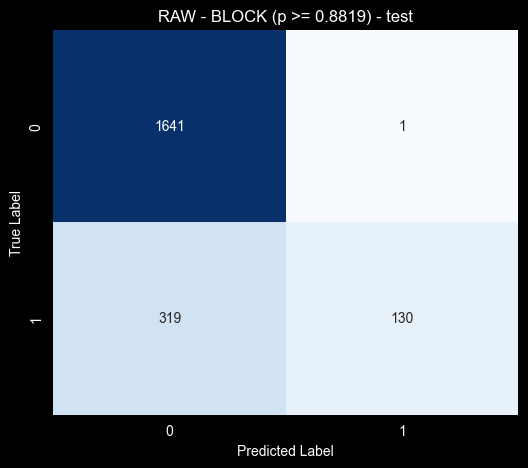

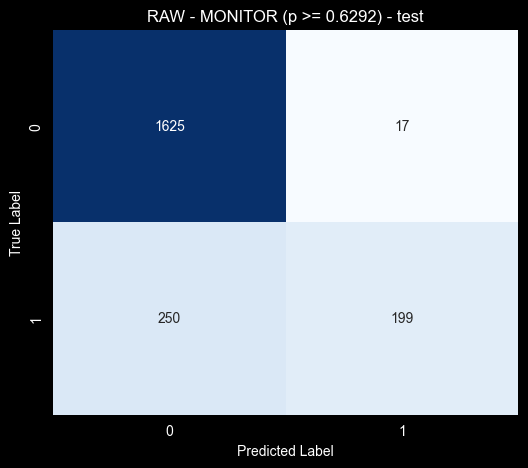


>>> MODE: ISOTONIC <<<


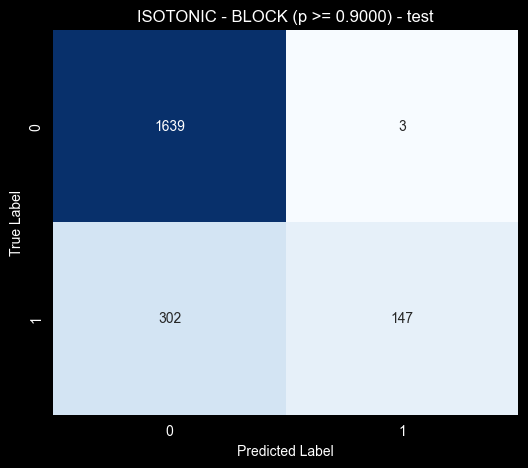

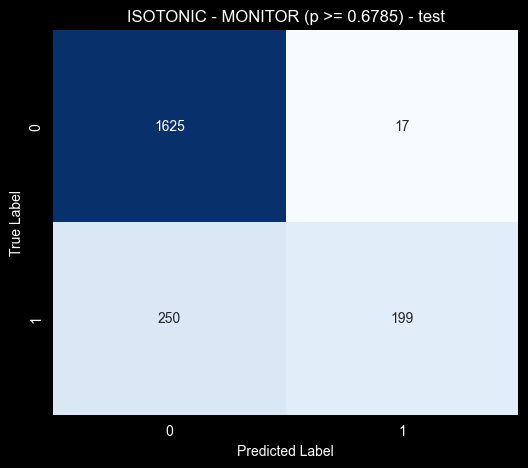


>>> MODE: PLATT <<<


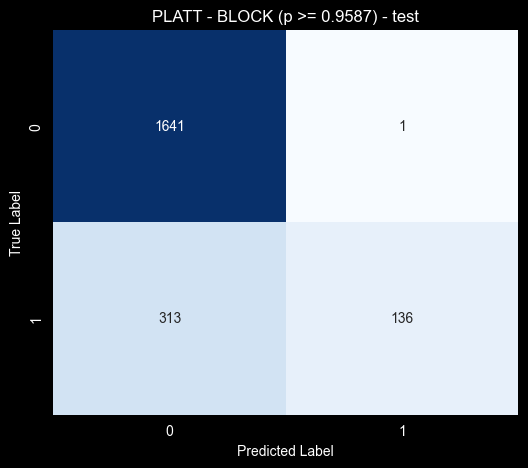

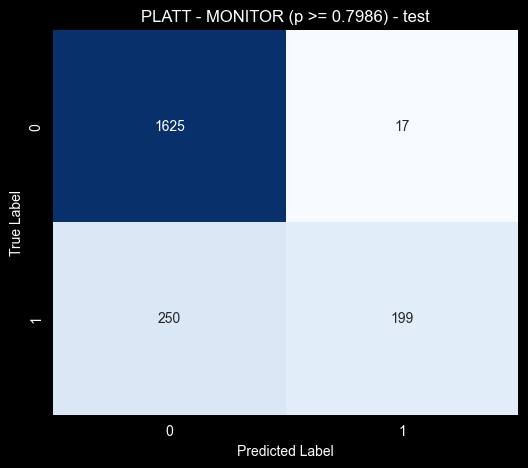

In [16]:
preds_path = paths.artifacts_dir / "balanced_bagging" / "predictions.csv"

if preds_path.exists():
    df_preds = pd.read_csv(preds_path)

    # Restore 'app' for protocol-specific evaluation if missing
    if "app" not in df_preds.columns and "app" in df_all.columns:
        # Merge back 'app' using flow_id and dataset as unique keys
        df_preds = df_preds.merge(df_all[["flow_id", "dataset", "app"]], on=["flow_id", "dataset"], how="left")

    # Also restore source_file if available and needed for USBVPN mapping
    if "source_file" not in df_preds.columns and "source_file" in df_all.columns:
        df_preds = df_preds.merge(df_all[["flow_id", "dataset", "source_file"]], on=["flow_id", "dataset"], how="left")

    # Check for required columns
    required_cols = ["prob_raw", "prob_iso", "prob_platt"]
    missing = [c for c in required_cols if c not in df_preds.columns]
    if missing:
        raise ValueError(f"Missing probability columns in predictions.csv: {missing}")

    print("\nPredictions columns:")
    print(df_preds.columns.tolist())

    # ----------------------------
    # Comparison: Raw vs Isotonic vs Platt (Per Dataset)
    # ----------------------------
    print("\n" + "="*60)
    print("CALIBRATION COMPARISON (PER DATASET)")
    print("="*60)

    for split_name in ["val", "test"]:
        sub_split = df_preds[df_preds["split"] == split_name].copy()
        if sub_split.empty:
            continue

        print(f"\n--- SPLIT: {split_name.upper()} ---")

        datasets = ["overall"] + sorted(sub_split["dataset"].unique().tolist())

        for ds in datasets:
            if ds == "overall":
                sub = sub_split
            else:
                sub = sub_split[sub_split["dataset"] == ds]

            y = sub["label"].astype(int)

            if len(np.unique(y)) < 2:
                continue

            print(f"\n  Dataset: {ds.upper()} (n={len(sub)})")

            stats = []
            for mode, col in [("Raw", "prob_raw"), ("Isotonic", "prob_iso"), ("Platt", "prob_platt")]:
                p = sub[col]
                auc = roc_auc_score(y, p)
                ap = average_precision_score(y, p)

                stats.append({
                    "Mode": mode,
                    "AUC": auc,
                    "PR_AUC": ap,
                })

            print(pd.DataFrame(stats).to_string(index=False, float_format="%.4f"))

    # ----------------------------
    # Firewall Policy Evaluation (Detailed by Dataset)
    # ----------------------------
    print("\n" + "="*60)
    print("FIREWALL POLICY METRICS (TEST SET, ISOTONIC CALIBRATION)")
    print("="*60)

    # Load thresholds from metrics.json
    with open(paths.artifacts_dir / "balanced_bagging" / "metrics.json", "r") as f:
        metrics_loaded = json.load(f)

    val_iso_metrics = metrics_loaded.get("isotonic", {}).get("val", {})
    t_block = val_iso_metrics.get("fpr_0.001", {}).get("threshold", 0.99)
    t_monitor = val_iso_metrics.get("fpr_0.01", {}).get("threshold", 0.95)

    print(f"Calibrated Thresholds:")
    print(f"  BLOCK (0.1% FPR Target): p >= {t_block:.4f}")
    print(f"  MONITOR (1% FPR Target): p >= {t_monitor:.4f}")

    test_preds = df_preds[df_preds["split"] == "test"].copy()

    eval_results = []

    def evaluate_subset(subset_df, subset_name):
        if subset_df.empty:
            return

        y_true = subset_df["label"].astype(int).values
        p_iso = subset_df["prob_iso"].values

        for policy, threshold in [("BLOCK", t_block), ("MONITOR", t_monitor)]:
            y_pred = (p_iso >= threshold).astype(int)

            # Avoid issues with missing classes in small subsets
            if len(np.unique(y_true)) > 1:
                tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            else:
                tp = np.sum((y_true == 1) & (y_pred == 1))
                tn = np.sum((y_true == 0) & (y_pred == 0))
                fp = np.sum((y_true == 0) & (y_pred == 1))
                fn = np.sum((y_true == 1) & (y_pred == 0))

            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

            eval_results.append({
                "Dataset": subset_name,
                "Policy": policy,
                "N_flows": len(subset_df),
                "Recall (VPN)": recall,
                "Precision": precision,
                "FPR (Non-VPN)": fpr
            })

    # Evaluate overall and per-dataset
    evaluate_subset(test_preds, "OVERALL")
    for ds in ["vnat", "iscx", "usbvpn"]:
        evaluate_subset(test_preds[test_preds["dataset"] == ds], ds.upper())

    print("\nPolicy Evaluation:")
    print(pd.DataFrame(eval_results).to_string(index=False, float_format="%.4f"))

    # ----------------------------
    # USBVPN WireGuard Specific Evaluation
    # ----------------------------
    # USBVPN might not have 'app' directly if it's extracted from source_file
    if "source_file" in test_preds.columns:
        wg_test = test_preds[(test_preds["dataset"] == "usbvpn") & (test_preds["source_file"].str.lower().str.contains("wireguard", na=False))].copy()
    elif "app" in test_preds.columns:
        wg_test = test_preds[(test_preds["dataset"] == "usbvpn") & (test_preds["app"].str.lower().str.contains("wireguard", na=False))].copy()
    else:
        wg_test = pd.DataFrame()

    if not wg_test.empty:
        print("\n" + "="*60)
        print("ZERO-SHOT PROTOCOL CAPABILITY: WIREGUARD (USBVPN TEST)")
        print("="*60)
        print(f"WireGuard Flows in USBVPN Test Set: {len(wg_test)}")

        # Since WireGuard is a VPN protocol, true label is 1. We just want to see if we recall them.
        wg_labels = wg_test["label"].astype(int).values
        wg_preds = wg_test["prob_iso"].values

        wg_block = (wg_preds >= t_block).astype(int)
        wg_monitor = (wg_preds >= t_monitor).astype(int)

        wg_block_recall = np.mean(wg_block == 1)
        wg_monitor_recall = np.mean(wg_monitor == 1)

        print(f"WireGuard Recall (BLOCK threshold):   {wg_block_recall:.4f}")
        print(f"WireGuard Recall (MONITOR threshold): {wg_monitor_recall:.4f}")
    else:
        print("\nNo WireGuard flows identified in USBVPN test set (check 'app' or 'source_file' column mapping).")

    # ----------------------------
    # Confusion Matrices at Policy Thresholds
    # ----------------------------
    print("\n" + "="*60)
    print("CONFUSION MATRICES (Test Set)")
    print("="*60)

    for mode, col in [("raw", "prob_raw"), ("isotonic", "prob_iso"), ("platt", "prob_platt")]:
        print(f"\n>>> MODE: {mode.upper()} <<<")

        # Get thresholds for this mode (tuned on val)
        val_metrics = metrics_loaded.get(mode, {}).get("val", {})

        def get_thr(m_dict, fpr):
            key = f"fpr_{fpr}"
            if key in m_dict: return m_dict[key]["threshold"]
            return 0.99

        t_b = get_thr(val_metrics, 0.001)
        t_m = get_thr(val_metrics, 0.01)

        plot_confusion_matrices(
            test_preds,
            prob_col=col,
            threshold=t_b,
            title=f"{mode.upper()} - BLOCK (p >= {t_b:.4f})"
        )

        plot_confusion_matrices(
            test_preds,
            prob_col=col,
            threshold=t_m,
            title=f"{mode.upper()} - MONITOR (p >= {t_m:.4f})"
        )

else:
    print("Predictions file not found, skipping plots.")